In [1]:
import sys, os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import optuna
import seaborn as sns
from cycler import cycler
from matplotlib.ticker import ScalarFormatter
from scipy.interpolate import griddata

from pathlib import Path
sys.path.append(str(Path.cwd().parents[1]))
from im_net import datamanager, plotting
import datareader

plot_path = "./figures/Figure4"
plt.rcParams['figure.figsize'] = (2.2, 1.5)
plt.rcParams['figure.dpi'] = 300
plt.rcParams.update({'font.size': 8})

pid_palette = ['#ea535a', '#0066ac', '#9a26c8', '#eebbee', '#cadce0']
pid_cycler = cycler(color=pid_palette)
performance_palette = sns.color_palette('husl')
sns.set_palette(performance_palette)

# Best goal weights found by Bayesian optimisation (used as markers in Panel B)
best_params_ii = np.array([0.48, -0.16, 0.25, 0.04, -0.63])
best_value_ii = 1.7
best_params_i = np.array([-0.27, -0.68, 0.68, -0.77, -0.8])
best_value_i = 1.68

%load_ext autoreload
%autoreload 2

# Figure 4: Optimization Landscape

## Panel A: Grid Landscape

5D grid sweep over goal weights, visualised as a matrix of 2D heatmaps.
Each outer cell fixes two dimensions; each inner cell shows the remaining two.
The residual entropy dimension is fixed at $\gamma_{H_{\mathrm{res}}} = -1$.

**Training command:** see `slurm_scripts/grid_batch.sh`

In [ ]:
# TODO: set path to grid experiment folder containing Optuna .db files
storage_all = ''
db_list = os.listdir(storage_all)
df_list = [datareader.load_df_from_db(f'{storage_all}/{db}') for db in db_list]
merged_df = pd.concat(df_list)

indices = np.array(['params_g.r', 'params_g.c', 'params_g.red', 'params_g.syn', 'params_g.h_res'])
indices_plus = np.append(indices, 'value')
average_df = merged_df[indices_plus].groupby(indices.tolist(), as_index=False).median()
print(f"Loaded {len(merged_df)} grid runs, {len(average_df)} unique parameter combinations.")

Loaded 18750 grid runs, 3125 unique parameter combinations.


In [3]:
def round_to_plot(raw_values, range=np.array([1.0, 0.5, 0.0, -0.5, -1.0]), stepsize=0.25):
    indices = np.zeros_like(raw_values, dtype=int)
    for i, value in enumerate(range):
        indices[np.abs(value - raw_values) < stepsize] = i
    return indices

indices_ii = round_to_plot(raw_values=best_params_ii)
indices_i = round_to_plot(raw_values=best_params_i)

param_names = ['params_g.r', 'params_g.c', 'params_g.red', 'params_g.syn', 'params_g.h_res']
atom_names = [
    r'Target Unique $\gamma_{unq,T}$', r'Recc. Unique $\gamma_{unq,R}$',
    r'Redundancy $\gamma_{red}$', r'Synergy $\gamma_{syn}$', r'Residual Entropy $H_{res}$'
]
# Dimension order: [outer1, outer2, inner1, inner2, fixed]
dim_order = [datareader.EXTERNAL, datareader.REDUNDANCY, datareader.INTERNAL, datareader.SYNERGY, datareader.ENTROPY]
val = 0
fixed_param = {param_names[dim_order[-1]]: val}
outer_params = [param_names[dim_order[0]], param_names[dim_order[1]]]
inner_params = [param_names[dim_order[2]], param_names[dim_order[3]]]
outer_names = [atom_names[dim_order[0]], atom_names[dim_order[1]]]
inner_names = [atom_names[dim_order[2]], atom_names[dim_order[3]]]

df_reduced = average_df[average_df[param_names[dim_order[-1]]] == val]

Text(0.5, -0.05, 'Redundancy $\\gamma_{red}$')

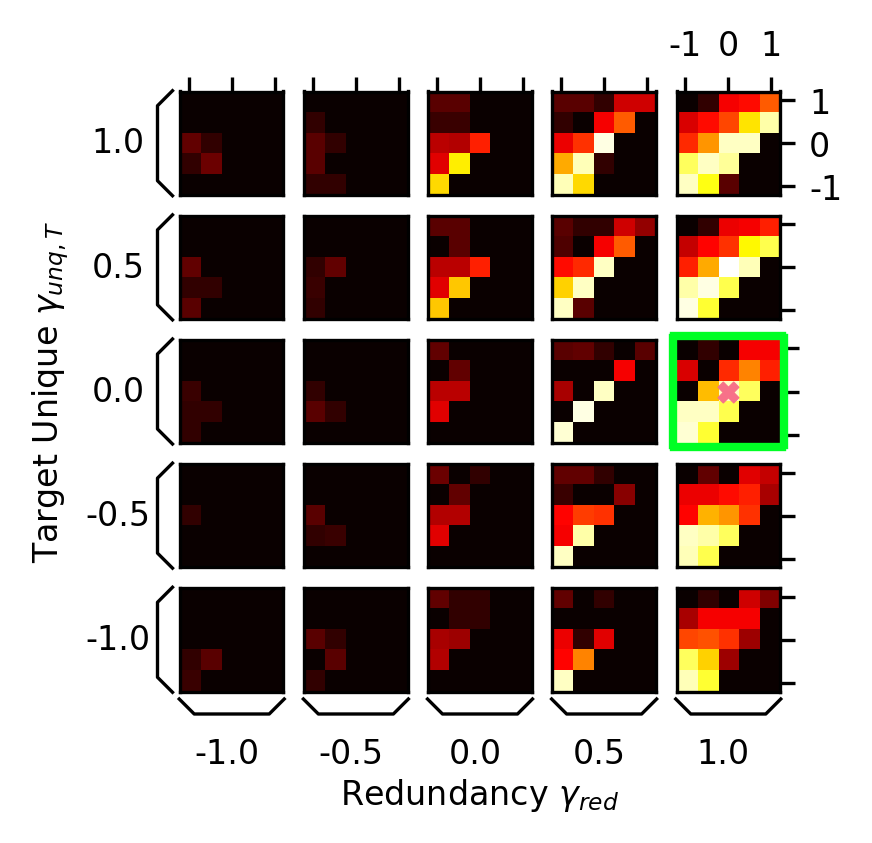

In [4]:
vals = [1.0, 0.5, 0.0, -0.5, -1.0]
ticks = [-1, 0, 1]
t_labels = [-1, 0, 1]
n_steps = len(vals)
max_index = n_steps - 1

fig, axes = plt.subplots(n_steps, n_steps, figsize=(2.5, 2.5), sharex=False, sharey=False)
fig.subplots_adjust(left=0.1, right=0.9, top=0.9, bottom=0.1, hspace=0.2, wspace=0.2)

for i in range(n_steps):
    for j in range(n_steps):
        data = df_reduced[
            (df_reduced[outer_params[0]] == vals[i]) &
            (df_reduced[outer_params[1]] == vals[max_index - j])
        ]
        filled_values = np.flipud(data.sort_values(by=inner_params)['value'].values.reshape(n_steps, n_steps))
        axes[i, j].imshow(filled_values / 100, vmax=1.70, vmin=0, cmap=plt.cm.hot,
                          aspect='auto', extent=[-1.2, 1.2, -1.2, 1.2])
        axes[i, j].tick_params(top=True, labeltop=True, bottom=False, labelbottom=False)
        axes[i, j].yaxis.tick_right()
        if i != 0:
            axes[i, j].set_xticks([])
        if j != max_index:
            axes[i, j].set_yticks([])
        axes[i, j].set_xticklabels([])
        axes[i, j].set_yticklabels([])

# # Mark optimisation results and redundancy baseline
axes[2, 4].scatter(0, 0, marker='X', lw=0.3, s=25, label='Redundancy')

# Highlight the redundancy cell
for spine in axes[2, max_index].spines.values():
    spine.set_edgecolor('#00ff25ff')
    spine.set_linewidth(2)
    spine.set_bounds(-1.25, 1.25)
    spine.set_position(('outward', 0.9))

# Axis brackets and outer labels
for j in range(n_steps):
    plotting.draw_brackets(axes[max_index, j], 'bottom', outset=0.01)
    plotting.draw_brackets(axes[j, 0], 'left', outset=0.01)
for i in range(n_steps):
    axes[i, 0].annotate(f'{vals[i]}', xy=(-0.6, 0.5), xycoords='axes fraction', ha='center', va='center')
    axes[max_index, i].annotate(f'{vals[4-i]}', xy=(0.45, -0.6), xycoords='axes fraction', ha='center', va='center')

axes[0, max_index].set_yticks(ticks)
axes[0, max_index].set_yticklabels(t_labels)
axes[0, max_index].set_xticks(ticks)
axes[0, max_index].set_xticklabels(t_labels)
fig.text(-0.1, 0.5, outer_names[0], va='center', rotation=90)
fig.text(0.5, -0.05, outer_names[1], ha='center')
# fig.savefig(f'{plot_path}/grid.svg', bbox_inches='tight')

## Panel B: 2D Slice

2D slice through the landscape, fixing three goal-weight dimensions at the optimised values
and sweeping over $\gamma_{\mathrm{unq,R}}$ and $\gamma_{\mathrm{syn}}$.

**Training command:** see `slurm_scripts/2d_slice.sh`
(add `goal/sweeps=slice_2d` to the grid batch script)

In [ ]:
def load_slice_df(storage_all, max_seed=19):
    """Load and median-aggregate a 2D slice experiment from a folder of Optuna .db files."""
    db_list = os.listdir(storage_all)
    df_list = [datareader.load_df_from_db(f'{storage_all}/{db}') for db in db_list]
    merged_df = pd.concat(df_list)
    filtered_df = merged_df[pd.Series(merged_df['user_attrs_params.seed'], dtype=int) <= max_seed]
    indices = np.array(['params_g.l', 'params_g.syn'])
    indices_plus = np.append(indices, 'value')
    average_df = filtered_df[indices_plus].groupby(indices.tolist(), as_index=False).median()
    average_df = average_df[(average_df['params_g.l'] <= 1) & (average_df['params_g.syn'] <= 1.)]
    return average_df

# --- Slice 1 (TODO: set path and marker/title) ---
storage_1 = ''
marker_1 = (0, 0)
title_1 = (rf'$\Pi_{{\mathrm{{unq,T}}}}=0$' + '\n'
           rf'$\Pi_{{\mathrm{{red}}}}=1$' + '\n'
           rf'$H_{{\mathrm{{res}}}}=0$')

# --- Slice 2 ---
storage_2 = ''
marker_2 = (best_params_i[3], best_params_i[1])
title_2 = (rf'$\Pi_{{\mathrm{{unq,T}}}}={best_params_i[0]}$' + '\n'
           rf'$\Pi_{{\mathrm{{red}}}}={best_params_i[2]}$' + '\n'
           rf'$H_{{\mathrm{{res}}}}={best_params_i[4]}$')


# --- Slice 3 (TODO: set path and marker/title) ---
storage_3 = ''
marker_3 = (best_params_ii[3], best_params_ii[1])
title_3 = (rf'$\Pi_{{\mathrm{{unq,T}}}}={best_params_ii[0]}$' + '\n'
           rf'$\Pi_{{\mathrm{{red}}}}={best_params_ii[2]}$' + '\n'
           rf'$H_{{\mathrm{{res}}}}={best_params_ii[4]}$')


avg_1 = load_slice_df(storage_1)
avg_2 = load_slice_df(storage_2)
avg_3 = load_slice_df(storage_3)
print(f"Loaded {len(avg_1)}, {len(avg_2)}, {len(avg_3)} unique grid points per slice.")

Loaded 441, 441, 441 unique grid points per slice.


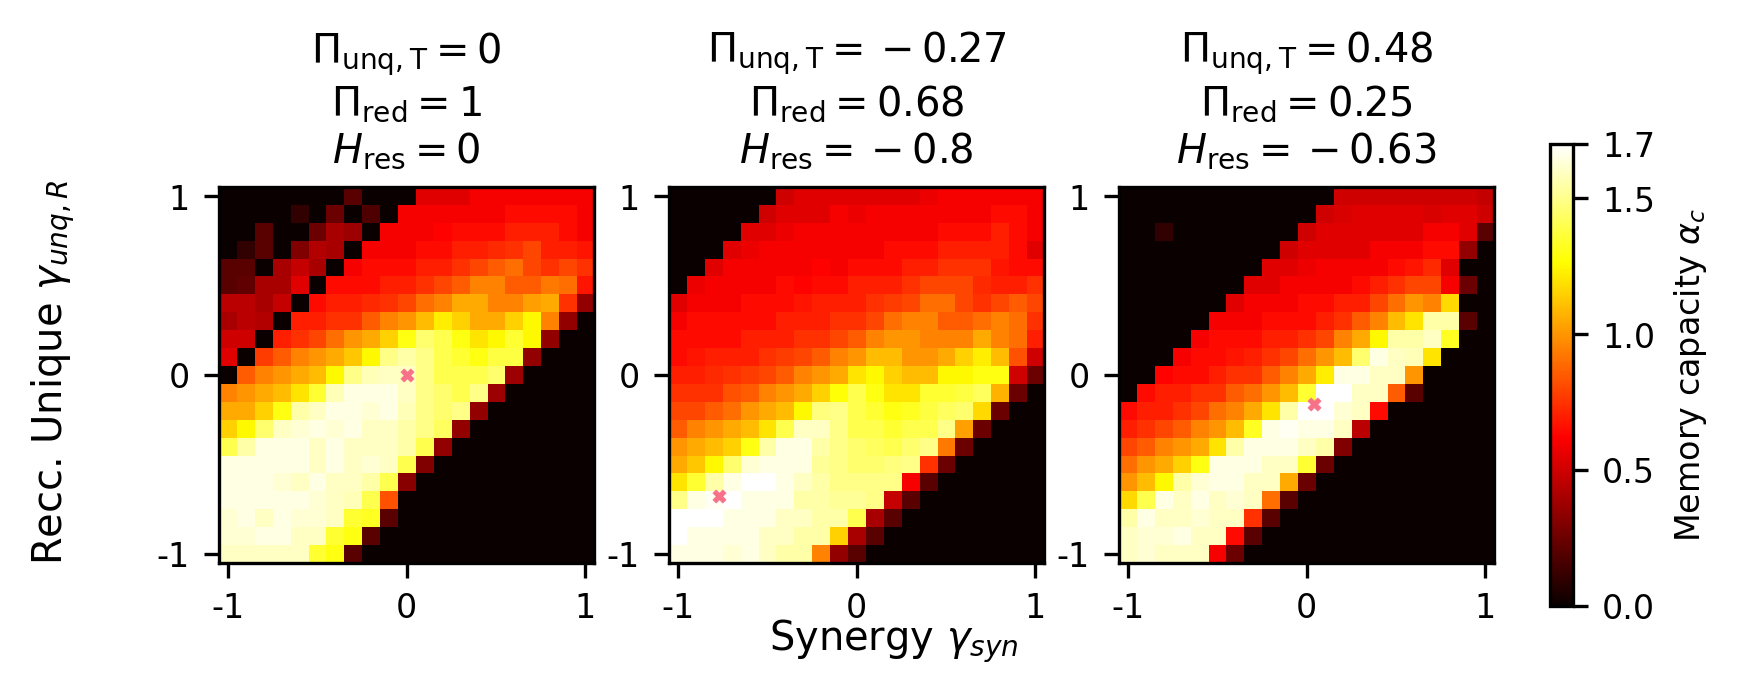

In [ ]:
slices = [
    (avg_1, marker_1, title_1),
    (avg_2, marker_2, title_2),
    (avg_3, marker_3, title_3),
]
step = 0.1

fig, axes = plt.subplots(1, 3, figsize=(6,2), )
for ax, (avg_df, marker, title) in zip(axes, slices):
    data = avg_df[['params_g.l', 'params_g.syn', 'value']].dropna()
    data_arr = np.flipud(
        data.sort_values(by=['params_g.l', 'params_g.syn'])['value'].values.reshape(21, 21)
    )
    min_x, max_x = avg_df['params_g.l'].min(), avg_df['params_g.l'].max()
    min_y, max_y = avg_df['params_g.syn'].min(), avg_df['params_g.syn'].max()

    im = ax.imshow(data_arr / 100, cmap=plt.cm.hot, aspect='auto',
                   extent=[min_x - step/2, max_x + step/2, min_y - step/2, max_y + step/2],
                   vmin=0, vmax=1.7)
    ax.scatter(*marker, marker='X', lw=0.15, s=10)
    ax.set_title(title, y=1)
    ax.set_aspect('equal')
    ax.set_xticks([-1, 0, 1])
    ax.set_xticklabels([-1, 0, 1])
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels([-1, 0, 1])

fig.supxlabel(r'Synergy $\gamma_{syn}$')
fig.supylabel(r'Recc. Unique $\gamma_{unq,R}$')

cbar = fig.colorbar(im, ax=axes.tolist(), fraction=0.046, pad=0.04,
                    ticks=[0., 0.5, 1., 1.5, 1.7],
                    label=r'Memory capacity $\alpha_c$')
# fig.savefig(f'{plot_path}/slice_comparison.svg', bbox_inches='tight')